# PA 766 · Module 7 · Text classification with encoder models

**Workflow:** text → encoder → classification head → label and scores.

The first notebook produced vectors. A task-specific classifier adds a learned decision rule that maps text representations to a fixed set of labels.

## Setup

Run once in a fresh Python 3 session. Internet access is needed to download packages, models, and the movie-review dataset. A Colab T4 GPU is helpful; CPU also works with the samples below. Run the sections in order.

**Data files:** Upload `solar-energy-messages-sample.csv` through Colab's Files sidebar for Part 1. Parts 2 and 3 read prepared CSVs from Google Drive, using the Drive mount and `YourPath` defined in Part 2. Part 3 reads `AG News/ag-news-test-sample-400.csv` under that data folder without downloading or resampling AG News.

In [ ]:
%pip install -q transformers torch datasets pandas matplotlib scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from time import perf_counter
from IPython.display import display
from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 16 if torch.cuda.is_available() else 8
pd.set_option("display.max_colwidth", 240)
print("Using", "GPU" if DEVICE == 0 else "CPU")

Using GPU


## Part 1. Movie-review sentiment

This is **binary** classification (two possible labels), while solar sentiment is **multiclass** (three). Both assign one label per text. **Multilabel** classification can assign several labels to one text and is not used here.

We load 200 reproducibly sampled reviews from the [Rotten Tomatoes test split](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes). The model was trained on SST-2; both corpora trace to related movie-review material, so this is evaluation practice, not a claim of an independently audited benchmark.

In [ ]:
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
YourPath = "/content/drive/MyDrive/a-ncsu-courses/PA766-2026/Data/" # Replace with your path!
movie_sample = pd.read_csv(Path(YourPath + "Movie Reviews/movie_sample.csv"))

In [ ]:
movie_sample["category"] = movie_sample["label"].map({0: "negative", 1: "positive"})

display(movie_sample["category"].value_counts())
display(movie_sample[["text", "category"]].head())

,count
category,
positive,500
negative,500


,text,category
0,"the main story . . . is compelling enough , but it's difficult to shrug off the annoyance of that chatty fish .",positive
1,some motion pictures portray ultimate passion ; others create ultimate thrills . men in black ii achieves ultimate insignificance -- it's the sci-fi comedy spectacle as whiffle-ball epic .,negative
2,there is a general air of exuberance in all about the benjamins that's hard to resist .,positive
3,"though there are many tense scenes in trapped , they prove more distressing than suspenseful .",negative
4,"what we get in feardotcom is more like something from a bad clive barker movie . in other words , it's badder than bad .",negative


In [ ]:
movie_sample.to_csv("movie_sample.csv", index=False)

### Use the same workflow with a different classification head

[DistilBERT SST-2](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english) has two labels and no neutral option. Inspect its label mapping before predicting.

In [ ]:
MOVIE_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
MOVIE_LABELS = ["negative", "positive"]
movie_classifier = pipeline(
    "text-classification", model=MOVIE_MODEL, tokenizer=MOVIE_MODEL, device=DEVICE,
)
print(movie_classifier.model.config.id2label)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

{0: 'NEGATIVE', 1: 'POSITIVE'}


In [ ]:
raw_movie_predictions = movie_classifier(  # Run the sentiment classifier
    movie_sample["text"].tolist(), batch_size=BATCH_SIZE,  # Classify the review texts in batches
    truncation=True, max_length=256, top_k=None,  # Limit text length and return all label scores
)

In [ ]:
movie_probabilities = pd.DataFrame([  # Put the scores into a table
    {item["label"].lower(): item["score"] for item in result}  # Match each label to its score
    for result in raw_movie_predictions  # Do this for every review
])

In [ ]:
movie_sample["prediction"] = movie_probabilities.idxmax(axis=1)  # Pick the highest-scoring label
movie_sample["confidence"] = movie_probabilities.max(axis=1)  # Save its score
movie_sample[[f"prob_{label}" for label in MOVIE_LABELS]] = (  # Add a probability column for each label
    movie_probabilities[MOVIE_LABELS].to_numpy()  # Copy the scores into those columns
)
display(movie_sample[[  # Show the selected columns
    "text", "category", "prediction", "confidence", "prob_negative", "prob_positive",
]].head(6).round(3))  # Show the first six rows, rounded to three decimals

In [ ]:
print(classification_report(  # Print a summary of prediction accuracy
    movie_sample["category"], movie_sample["prediction"],  # Compare true and predicted labels
    labels=MOVIE_LABELS, digits=3, zero_division=0,  # Set label order and report formatting
))

              precision    recall  f1-score   support

    negative      0.891     0.898     0.894       500
    positive      0.897     0.890     0.894       500

    accuracy                          0.894      1000
   macro avg      0.894     0.894     0.894      1000
weighted avg      0.894     0.894     0.894      1000



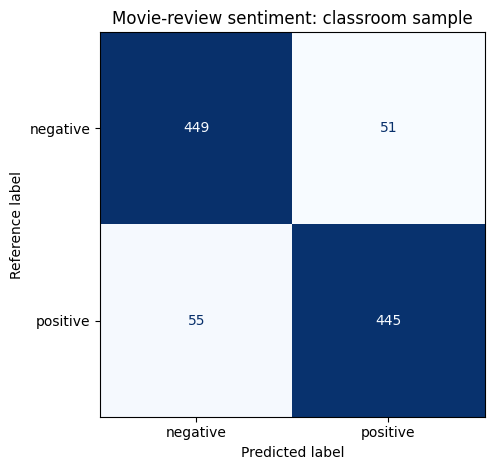

In [ ]:
ConfusionMatrixDisplay.from_predictions(  # Draw a confusion matrix
    movie_sample["category"], movie_sample["prediction"],  # Use true and predicted labels
    labels=MOVIE_LABELS, cmap="Blues", colorbar=False,  # Set label order and appearance
)
plt.title("Movie-review sentiment: classroom sample")  # Add a title
plt.ylabel("Reference label")  # Label the vertical axis
plt.tight_layout()  # Adjust spacing
plt.show()  # Display the chart

In [ ]:
movie_errors = movie_sample[
    movie_sample["category"] != movie_sample["prediction"]
].sort_values("confidence", ascending=False)
display(movie_errors[["text", "category", "prediction", "confidence"]].head(5))

,text,category,prediction,confidence
128,an encouraging effort from mccrudden,negative,positive,0.999872
930,"never again , while nothing special , is pleasant , diverting and modest -- definitely a step in the right direction .",negative,positive,0.999864
273,"seeing as the film lacks momentum and its position remains mostly undeterminable , the director's experiment is a successful one .",negative,positive,0.999823
325,"i just saw this movie . . . well , it's probably not accurate to call it a movie .",positive,negative,0.999803
38,too daft by half . . . but supremely good natured .,negative,positive,0.999796


**Your turn**

1. Which movie-review class has lower recall? Cite the report.
2. Read three confident errors. Do they involve negation, mixed sentiment, sarcasm, or debatable labels?
3. Why can the same pipeline code return three possible labels for one model and two for another?

## Part 2. Solar-energy sentiment


The CSV contains 1,000 messages with `tweet_id`, `text`, `created_at`, and `category`. We use all 1,000 messages in `solar_data`. `tweet_id` stays a string so its digits are preserved.

Here, `category` is the **supplied reference label**. The file does not document how each label was created or whether these messages were excluded from model training. Treat the metrics as agreement with supplied labels, not an independently verified accuracy estimate.

In [ ]:
YourPath = "/content/drive/MyDrive/a-ncsu-courses/PA766-2026/Data/" # Replace with your path!

solar_data = pd.read_csv(Path(YourPath + "Twitter Solar Energy/solar-energy-messages-sample.csv"), dtype={"tweet_id": "string"})

solar_data["category"] = solar_data["category"].str.strip().str.lower()

In [23]:
print("Messages:", len(solar_data))
display(solar_data["category"].value_counts())
display(solar_data[["text", "category"]].head())

Messages: 1000


,count
category,
positive,622
negative,268
neutral,110


,text,category
0,"We can't get reasonably-priced healthcare (let alone universal), we can't get student loan relief, we can't get money for roads or investment in solar power or anything that'd be helpful, but we can get a totalitarian fundamentalist Chr...",negative
1,[NAME] Televisions Computers Solar panels all cheaper now than when first introduced That’s what happens with products of new technologies as they become popular.,positive
2,"Update: JPSS-2’s solar array is not deployed. One of the four panels in the array, exposed to sunlight even before the array unfolds, is generating enough power for the spacecraft for now.",neutral
3,"[NAME] I believe in common sense, our main source of energy is oil/or nuclear. But,we can inter-connect solar and wind as an additional source but NOT as a substitute. We SHOULD be planting more trees, we should be able to turn our ocea...",positive
4,Today in the Biden admin: Fees for solar and wind projects on federal land are cut in half New sanctions on Russian oligarchs $5.8B in student loans forgiven for 560k Corinthian College students Yemen cease fire extended 2 more months ...,neutral


**Before prediction:** Draft a one-sentence rule for each sentiment label. Is the target sentiment about solar energy or the message's overall tone? Read three messages with a partner and discuss any ambiguous reference labels.

### Load the solar classifier

[Solar RoBERTa](https://huggingface.co/serenakim/solar-sentiment) was fine-tuned for this domain. Its configuration defines the labels; inspect them rather than guessing from their numeric IDs. See the [solar-sentiment study](https://doi.org/10.1007/s42001-025-00365-z) for the research context.

In [ ]:
SOLAR_MODEL = "serenakim/solar-sentiment"  # Hugging Face model checkpoint
SOLAR_LABELS = ["negative", "neutral", "positive"]  # Expected sentiment categories

solar_classifier = pipeline(
    "text-classification",  # Create a classifier that predicts a text label
    model=SOLAR_MODEL,       # Load the model from this checkpoint
    tokenizer=SOLAR_MODEL,   # Load its matching tokenizer
    device=DEVICE,           # Run on the device selected earlier
)

# Show the labels stored in the model, indexed by their numeric IDs.
print(solar_classifier.model.config.id2label)

### Predict and inspect scores

`top_k=None` returns every class score. `max_length=256` truncates longer inputs to 256 tokens. We select the highest-scoring label. The highest score is called **confidence** here; it is not a guarantee of correctness.

In [ ]:
raw_solar_predictions = solar_classifier(
    solar_data["text"].tolist(),  # Convert the text column to a list of inputs
    batch_size=BATCH_SIZE,        # Process this many texts at a time
    truncation=True,              # Shorten texts that exceed the token limit
    max_length=256,               # Keep at most 256 tokens per text
    top_k=None,                   # Return scores for every sentiment label
)

In [ ]:
# Turn each text's label scores into one row of a DataFrame.
solar_probabilities = pd.DataFrame([
    {item["label"].lower(): item["score"] for item in result}
    for result in raw_solar_predictions
])

# Select the label with the highest score for each text.
solar_data["prediction"] = solar_probabilities.idxmax(axis=1)

# Save that highest score as the model's confidence.
solar_data["confidence"] = solar_probabilities.max(axis=1)

# Add a separate score column for each sentiment label.
solar_data[[f"prob_{label}" for label in SOLAR_LABELS]] = (
    solar_probabilities[SOLAR_LABELS].to_numpy()
)

# Display the first six texts with their labels, predictions, and scores.
display(solar_data[[
    "text", "category", "prediction", "confidence",
    "prob_negative", "prob_neutral", "prob_positive",
]].head(6).round(3))

### Evaluate agreement with the reference labels

- **Precision:** Of messages predicted as a class, how many have that reference label?
- **Recall:** Of messages with a reference label, how many did the model identify?
- **F1:** Combines precision and recall. **Macro-F1** gives each class equal weight.

The confusion matrix has reference labels in rows and predictions in columns. The file has more positive than neutral messages, so inspect per-class results as well as overall accuracy.

In [ ]:
print(classification_report(  # Print a summary of prediction accuracy
    solar_data["category"], solar_data["prediction"],  # Compare supplied and predicted labels
    labels=SOLAR_LABELS, digits=3, zero_division=0,  # Set label order and report formatting
))
ConfusionMatrixDisplay.from_predictions(  # Draw a confusion matrix
    solar_data["category"], solar_data["prediction"],  # Use supplied and predicted labels
    labels=SOLAR_LABELS, cmap="Blues", colorbar=False,  # Set label order and appearance
)
plt.title("Solar sentiment: agreement with supplied labels")  # Add a title
plt.ylabel("Reference label")  # Label the vertical axis
plt.tight_layout()  # Adjust spacing
plt.show()  # Display the chart

In [ ]:
solar_errors = solar_data[
    solar_data["category"] != solar_data["prediction"]
].sort_values("confidence", ascending=False)
display(solar_errors[["text", "category", "prediction", "confidence"]].head(5))

**Discuss:** Which class has the lowest recall? Read three disagreements. Is each a model mistake, an ambiguous reference label, or a difference in what sentiment is being measured? Use `solar_errors.iloc[0]["text"]` to read a truncated message in full.

## Part 3. News classification with RoBERTa — YOUR TURN

Follow the same workflow as Part 2, now using [RoBERTa fine-tuned on AG News](https://huggingface.co/textattack/roberta-base-ag-news) to assign one of four topics: **World, Sports, Business, or Sci/Tech**.

Run the setup and Part 2 first so Drive is mounted and `YourPath` is defined. The prepared file is:

`/content/drive/MyDrive/a-ncsu-courses/PA766-2026/Data/AG News/ag-news-test-sample-400.csv`

It contains 400 articles sampled without replacement from the 7,600-row [AG News test split](https://huggingface.co/datasets/fancyzhx/ag_news), using `random_state=42`. Its columns are `text`, numeric `label`, named `category`, and `source_row` (the original test-split row). Keep this sample fixed for the exercise.

**Complete two items:** the prediction-label line marked **TODO 1** and the short response marked **TODO 2**. The remaining code is provided.

### Load the prepared sample

In [ ]:
news_sample = pd.read_csv(Path(YourPath + "AG News/ag-news-test-sample-400.csv"))

In [ ]:
NEWS_LABELS = ["World", "Sports", "Business", "Sci/Tech"]
news_sample["category"] = news_sample["label"].map(dict(enumerate(NEWS_LABELS)))

print("Articles:", len(news_sample))
display(news_sample["category"].value_counts())
display(news_sample[["source_row", "text", "category"]].head())

### Load RoBERTa and inspect its labels

This checkpoint returns `LABEL_0` through `LABEL_3` in AG News's class order. The mapping below converts those names to the categories in our data. The pipeline structure is the same as Part 2; the model and classification labels change.

In [ ]:
NEWS_MODEL = "textattack/roberta-base-ag-news"
news_classifier = pipeline(
    "text-classification", model=NEWS_MODEL, tokenizer=NEWS_MODEL, device=DEVICE,
)
print(news_classifier.model.config.id2label)

news_label_map = {f"LABEL_{i}": name for i, name in enumerate(NEWS_LABELS)}
print("Category mapping:", news_label_map)

### Predict and put the scores into a table

As in Part 2, `top_k=None` returns every class score, and `max_length=256` limits each input to 256 tokens. Translate the model's labels into topic names before selecting a prediction.

In [ ]:
raw_news_predictions = news_classifier(  # Run the news classifier
    news_sample["text"].tolist(), batch_size=BATCH_SIZE,
    truncation=True, max_length=256, top_k=None,
)

In [ ]:
news_probabilities = pd.DataFrame([  # Put one article's scores on each row
    {news_label_map[item["label"]]: item["score"] for item in result}
    for result in raw_news_predictions
])

### TODO 1. Select the predicted category

Replace `None` in the next cell with the expression that selects the **name of the highest-scoring category in each row** of `news_probabilities`. Use the corresponding line in Part 2 as your guide. Keep the rest of the cell as provided.

In [ ]:
news_sample["prediction"] = None  # TODO 1: replace None with your expression

if news_sample["prediction"].isna().any():
    raise ValueError("Complete TODO 1 before continuing. See the prediction line in Part 2.")

news_sample["confidence"] = news_probabilities.max(axis=1)  # Save the highest score
news_sample[[f"prob_{label}" for label in NEWS_LABELS]] = (
    news_probabilities[NEWS_LABELS].to_numpy()
)
display(news_sample[[
    "text", "category", "prediction", "confidence",
    *[f"prob_{label}" for label in NEWS_LABELS],
]].head(6).round(3))

### Evaluate predictions and inspect errors

Read the classification report and confusion matrix as in Part 2. The matrix has reference labels in rows and predictions in columns. The report includes overall accuracy and macro-F1, which gives each topic equal weight.

The error table lists the highest-confidence mistakes first. A high score does not guarantee a correct prediction.

In [ ]:
print(classification_report(
    news_sample["category"], news_sample["prediction"],
    labels=NEWS_LABELS, digits=3, zero_division=0,
))

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    news_sample["category"], news_sample["prediction"],
    labels=NEWS_LABELS, cmap="Blues", colorbar=False,
)
plt.title("AG News: RoBERTa on the 400-article sample")
plt.ylabel("Reference label")
plt.tight_layout()
plt.show()

In [ ]:
news_errors = news_sample[
    news_sample["category"] != news_sample["prediction"]
].sort_values("confidence", ascending=False)
display(news_errors[["source_row", "text", "category", "prediction", "confidence"]].head(5))

# Read the first error in full when the table truncates its text.
if not news_errors.empty:
    print(news_errors.iloc[0]["text"])

### TODO 2. Interpret the results


- Name the topic with the lowest recall and report its recall value.
- Choose one article from `news_errors`. Give its `source_row`, reference topic, and predicted topic. Explain briefly what in the text could have led to the mistake, or why the topic is ambiguous.
